# Task 3 – Exploratory Data Analysis (EDA)

## Smart City Public Safety Project

This notebook performs Exploratory Data Analysis on the Smart City Public Safety dataset.

### Objectives
- Understand the dataset structure
- Analyze categorical and numerical features
- Study the distribution of emergency levels
- Identify patterns between incident characteristics and emergency levels
- Analyze severity and response times
- Perform correlation analysis
- Extract meaningful insights from the dataset

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load the Dataset

The cleaned dataset generated during the data cleaning stage is loaded for Exploratory Data Analysis.

In [21]:
df = pd.read_csv("../data/smart_city_thiranex_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (10000, 15)


## 2. Dataset Overview

The dataset contains information about public safety incidents, including incident type, location, weather, crowd level, response times, severity score, and emergency level.

In [22]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Number of Rows: 10000
Number of Columns: 15

Column Names:
['Incident_ID', 'Incident_Type', 'Area', 'Time_of_Day', 'Day_of_Week', 'Weather', 'Crowd_Level', 'CCTV_Available', 'Police_Response_Time', 'Ambulance_Response_Time', 'Fire_Response_Time', 'Number_of_People', 'Severity_Score', 'Previous_Incidents', 'Emergency_Level']

First 5 Records:


,Incident_ID,Incident_Type,Area,Time_of_Day,Day_of_Week,Weather,Crowd_Level,CCTV_Available,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time,Number_of_People,Severity_Score,Previous_Incidents,Emergency_Level
0,1,Theft,Central,Morning,Friday,Rainy,Low,Yes,10.0,12,12,13,2,8,Medium
1,2,Medical,South,Night,Tuesday,Rainy,High,No,19.0,24,5,112,2,7,Medium
2,3,Accident,South,Afternoon,Sunday,Rainy,Low,Yes,25.0,18,25,389,1,5,Medium
3,4,Theft,West,Morning,Thursday,Sunny,High,No,14.0,24,20,50,7,11,High
4,5,Theft,South,Evening,Monday,Sunny,Low,No,21.0,11,8,454,10,11,High


## 3. Data Types and Statistical Summary

The data types and statistical summary are examined to understand the structure and numerical characteristics of the dataset.

In [23]:
print("Data Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

Data Types:
Incident_ID                  int64
Incident_Type                  str
Area                           str
Time_of_Day                    str
Day_of_Week                    str
Weather                        str
Crowd_Level                    str
CCTV_Available                 str
Police_Response_Time       float64
Ambulance_Response_Time      int64
Fire_Response_Time           int64
Number_of_People             int64
Severity_Score               int64
Previous_Incidents           int64
Emergency_Level                str
dtype: object

Statistical Summary:


,Incident_ID,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time,Number_of_People,Severity_Score,Previous_Incidents
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,13.847100,17.503000,19.46920,250.804300,5.464900,10.195200
std,2886.89568,6.583073,7.448566,9.27788,144.039548,2.880277,6.048599
min,1.00000,3.000000,5.000000,4.00000,1.000000,1.000000,0.000000
25%,2500.75000,8.000000,11.000000,11.00000,126.000000,3.000000,5.000000
50%,5000.50000,14.000000,18.000000,19.00000,252.000000,5.000000,10.000000
75%,7500.25000,19.000000,24.000000,28.00000,377.000000,8.000000,15.000000
max,10000.00000,25.000000,30.000000,35.00000,500.000000,10.000000,20.000000


## 4. Missing Values and Duplicate Records

The cleaned dataset is checked for missing values and duplicate records to confirm data quality before analysis.

In [24]:
print("Missing Values:")
display(df.isnull().sum())

print("Total Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:


Incident_ID                0
Incident_Type              0
Area                       0
Time_of_Day                0
Day_of_Week                0
Weather                    0
Crowd_Level                0
CCTV_Available             0
Police_Response_Time       0
Ambulance_Response_Time    0
Fire_Response_Time         0
Number_of_People           0
Severity_Score             0
Previous_Incidents         0
Emergency_Level            0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0


## 5. Emergency Level Distribution

This analysis shows the distribution of incidents across Low, Medium, and High emergency levels.

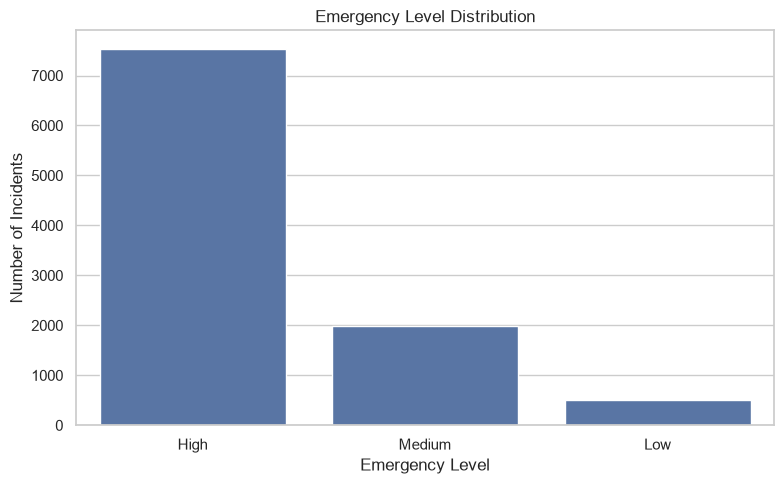

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Emergency_Level",
    order=df["Emergency_Level"].value_counts().index
)

plt.title("Emergency Level Distribution")
plt.xlabel("Emergency Level")
plt.ylabel("Number of Incidents")
plt.tight_layout()

plt.savefig("../visualizations/emergency_level_eda.png", dpi=300)
plt.show()

## 6. Incident Type Distribution

This analysis identifies the most frequently occurring types of public safety incidents.

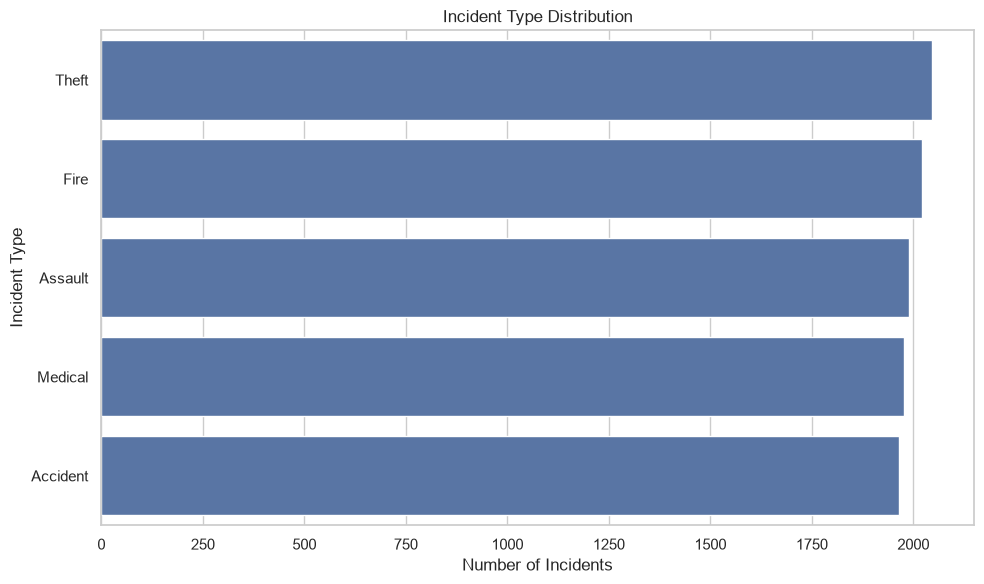

In [26]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Incident_Type",
    order=df["Incident_Type"].value_counts().index
)

plt.title("Incident Type Distribution")
plt.xlabel("Number of Incidents")
plt.ylabel("Incident Type")
plt.tight_layout()

plt.savefig("../visualizations/incident_type_eda.png", dpi=300)
plt.show()

## 7. Incidents by Area

This analysis shows how incidents are distributed across different areas.

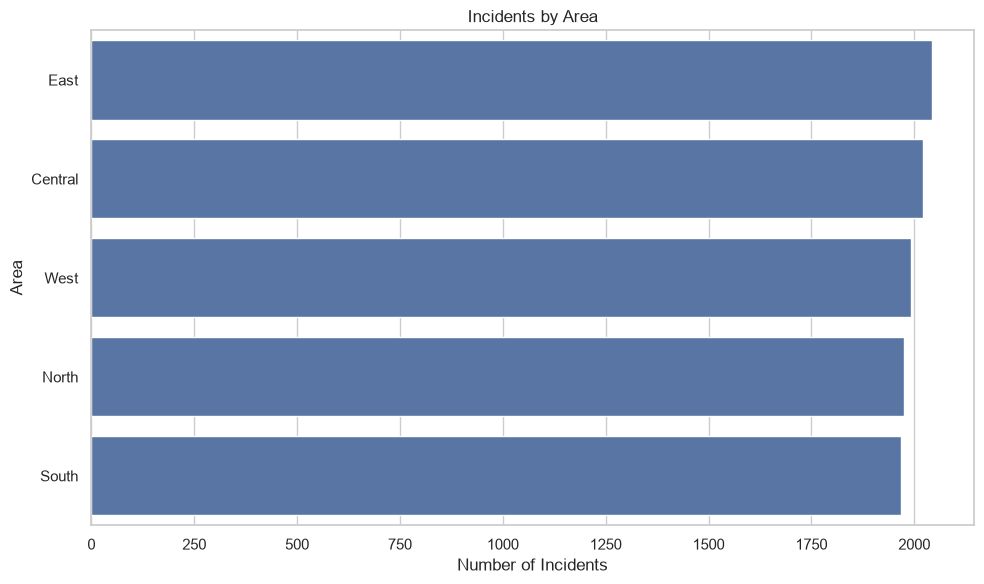

In [27]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Area",
    order=df["Area"].value_counts().index
)

plt.title("Incidents by Area")
plt.xlabel("Number of Incidents")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig("../visualizations/incidents_by_area_eda.png", dpi=300)
plt.show()

## 8. Emergency Level by Incident Type

This analysis examines the relationship between incident type and emergency level.

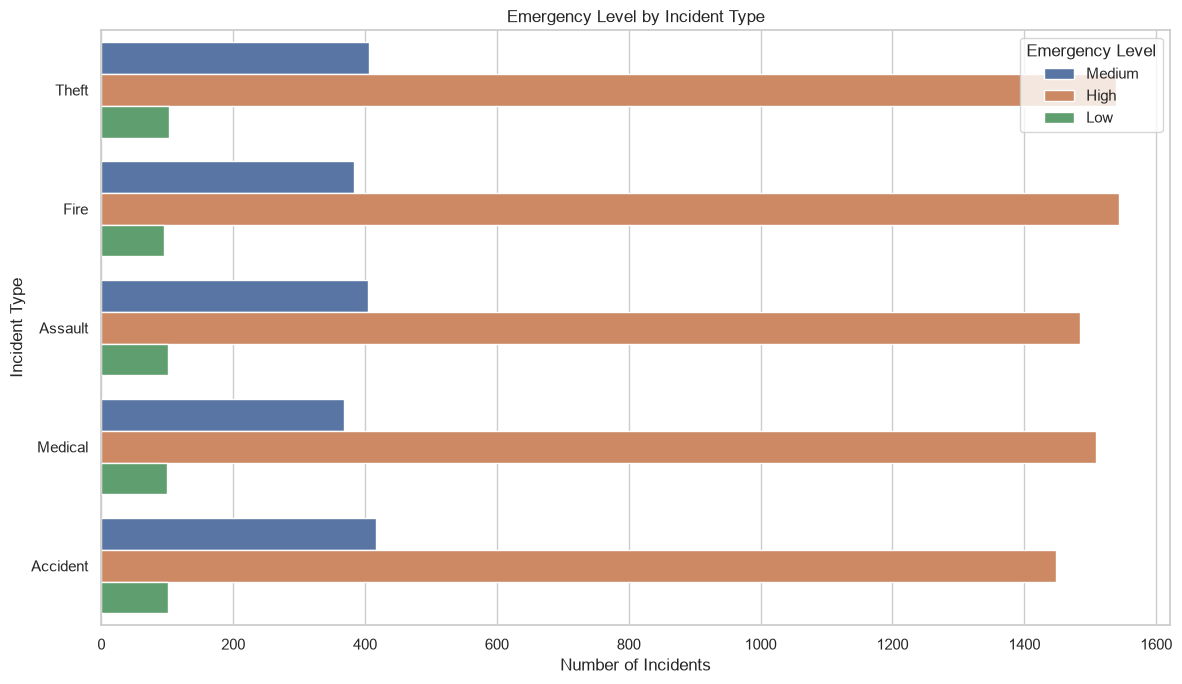

In [28]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="Incident_Type",
    hue="Emergency_Level",
    order=df["Incident_Type"].value_counts().index
)

plt.title("Emergency Level by Incident Type")
plt.xlabel("Number of Incidents")
plt.ylabel("Incident Type")
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/emergency_by_incident_type.png", dpi=300)
plt.show()

## 9. Emergency Level by Area

This analysis compares emergency levels across different areas.

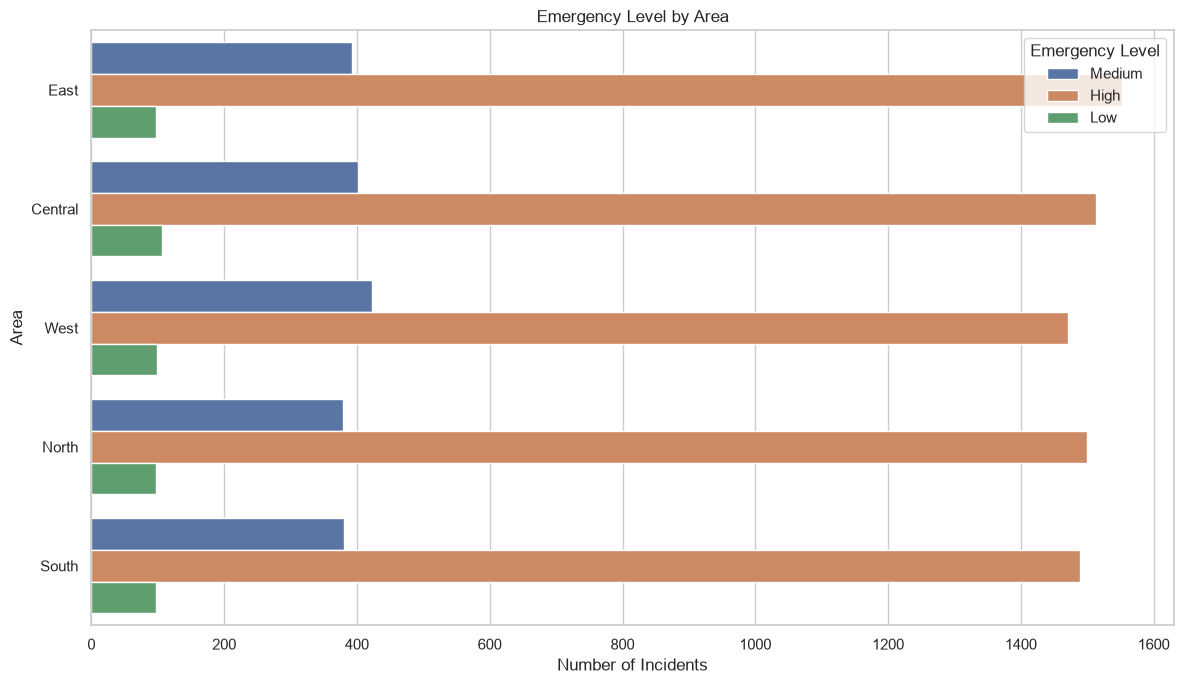

In [29]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="Area",
    hue="Emergency_Level",
    order=df["Area"].value_counts().index
)

plt.title("Emergency Level by Area")
plt.xlabel("Number of Incidents")
plt.ylabel("Area")
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/emergency_by_area.png", dpi=300)
plt.show()

## 10. Weather vs Emergency Level

This analysis examines whether emergency levels vary under different weather conditions.

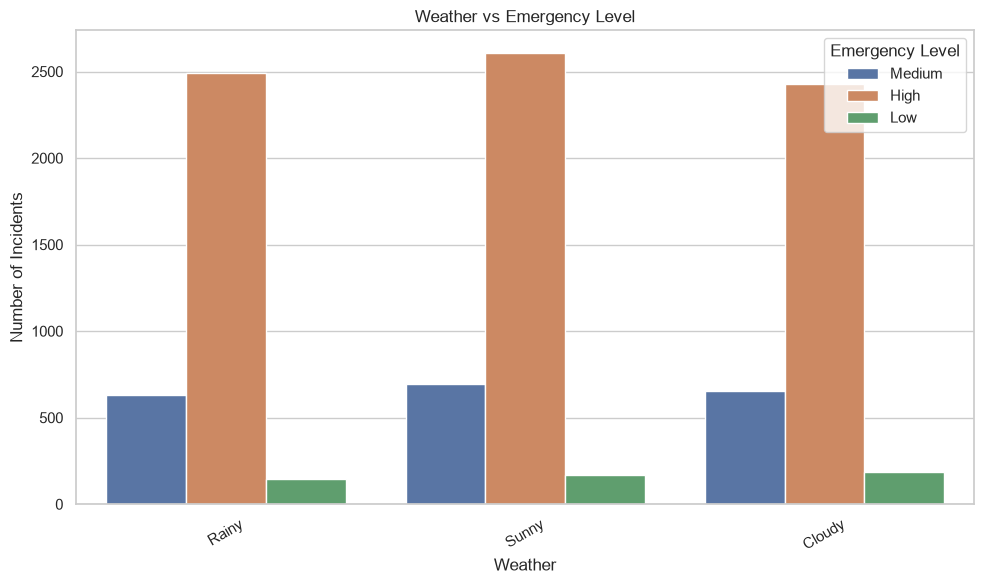

In [30]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Weather",
    hue="Emergency_Level"
)

plt.title("Weather vs Emergency Level")
plt.xlabel("Weather")
plt.ylabel("Number of Incidents")
plt.legend(title="Emergency Level")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../visualizations/weather_vs_emergency.png", dpi=300)
plt.show()

## 11. Crowd Level vs Emergency Level

This analysis examines the relationship between crowd level and emergency level.

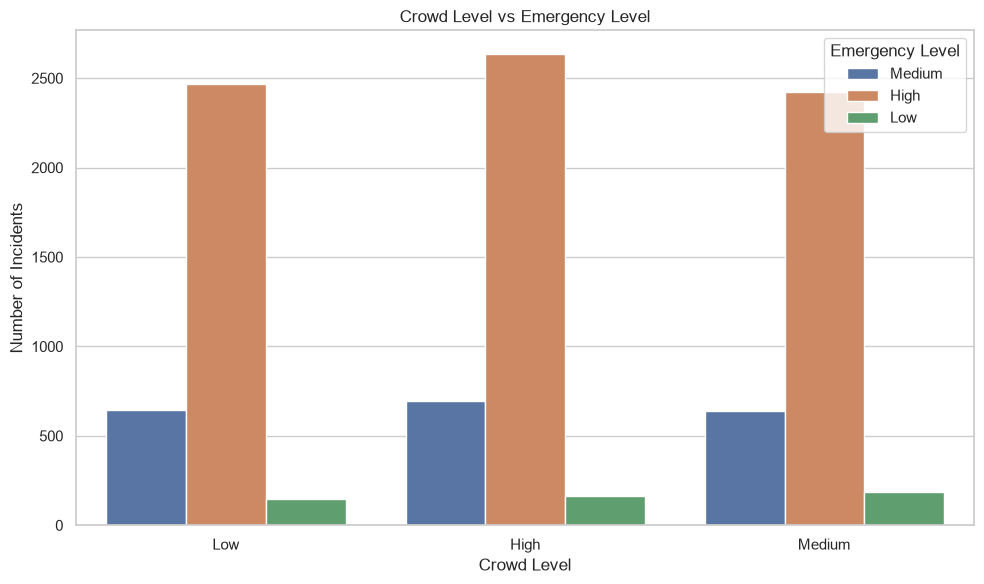

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Crowd_Level",
    hue="Emergency_Level"
)

plt.title("Crowd Level vs Emergency Level")
plt.xlabel("Crowd Level")
plt.ylabel("Number of Incidents")
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/crowd_vs_emergency.png", dpi=300)
plt.show()

## 12. Time of Day vs Emergency Level

This analysis examines emergency levels across different times of the day.

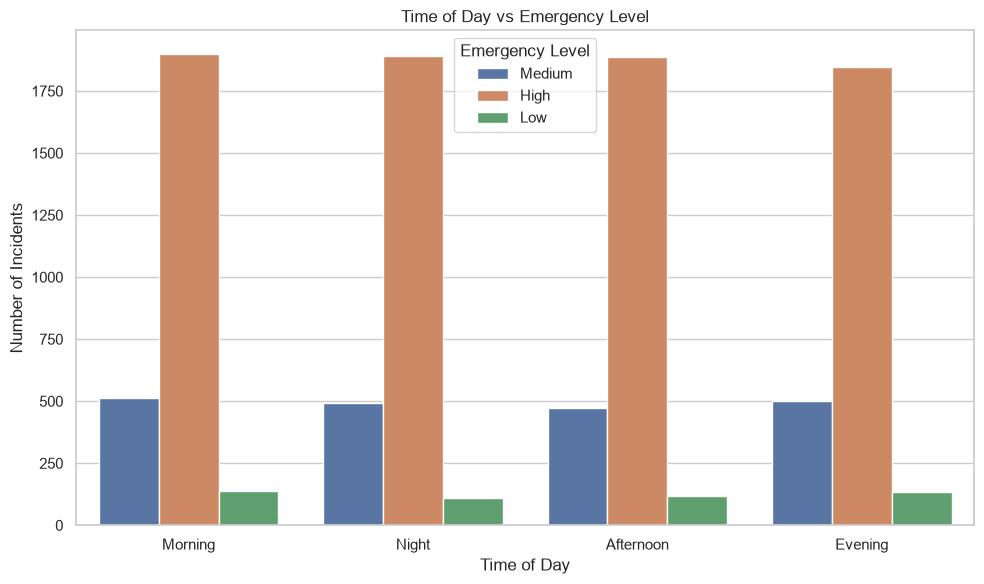

In [32]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Time_of_Day",
    hue="Emergency_Level"
)

plt.title("Time of Day vs Emergency Level")
plt.xlabel("Time of Day")
plt.ylabel("Number of Incidents")
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/time_of_day_vs_emergency.png", dpi=300)
plt.show()

## 13. Numerical Feature Distribution

The distributions of important numerical variables are analyzed.

### Numerical Features
- Police Response Time
- Ambulance Response Time
- Fire Response Time
- Number of People
- Severity Score
- Previous Incidents

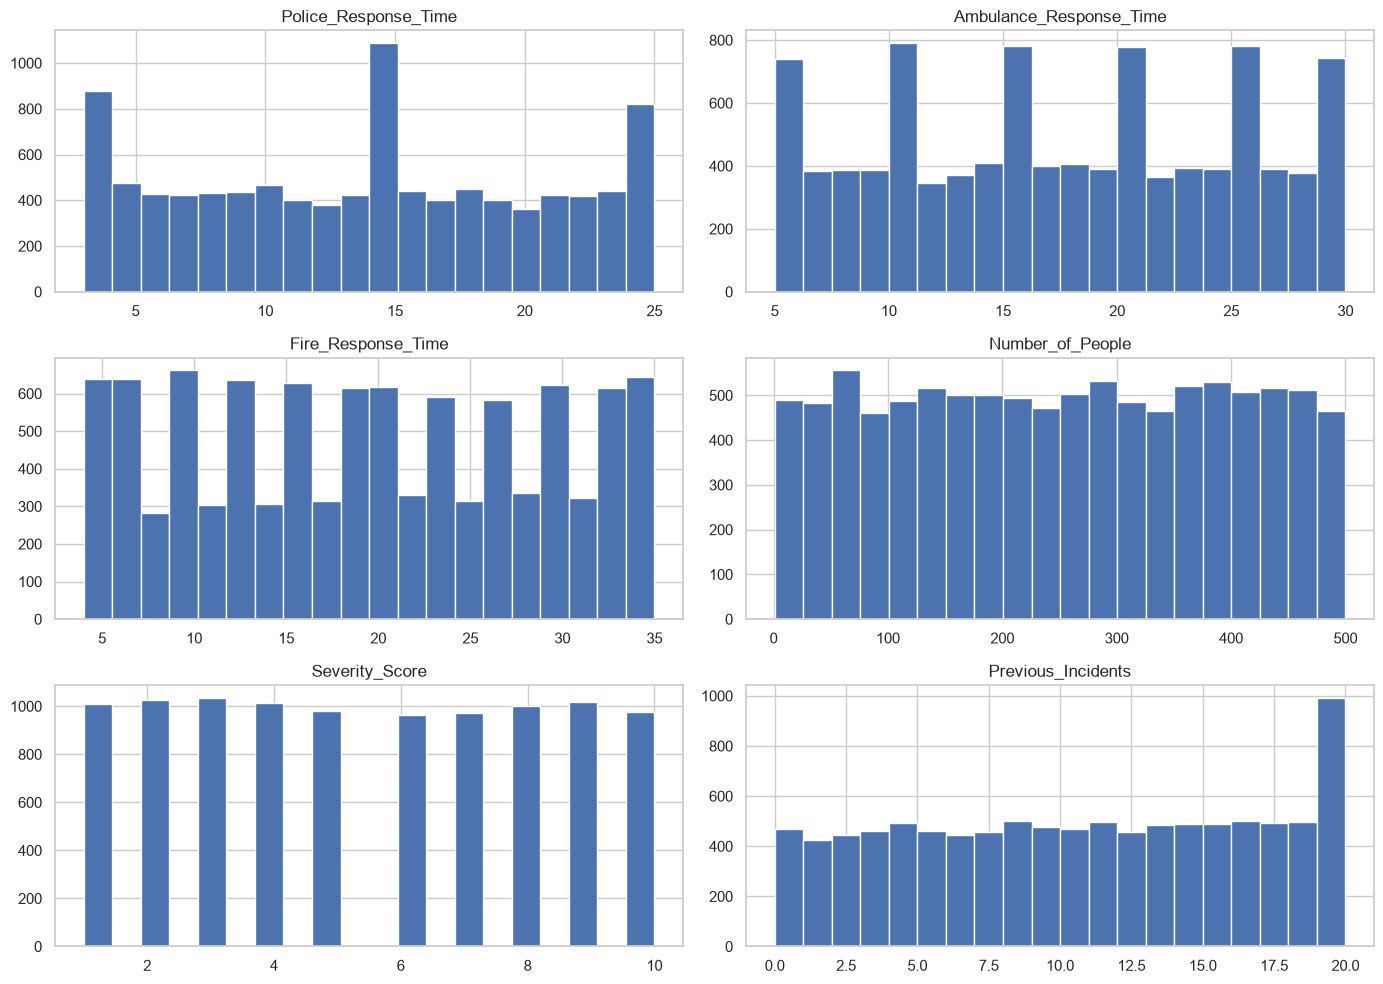

In [33]:
numeric_columns = [
    "Police_Response_Time",
    "Ambulance_Response_Time",
    "Fire_Response_Time",
    "Number_of_People",
    "Severity_Score",
    "Previous_Incidents"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

## 14. Severity Score by Emergency Level

This analysis compares severity scores across different emergency levels.

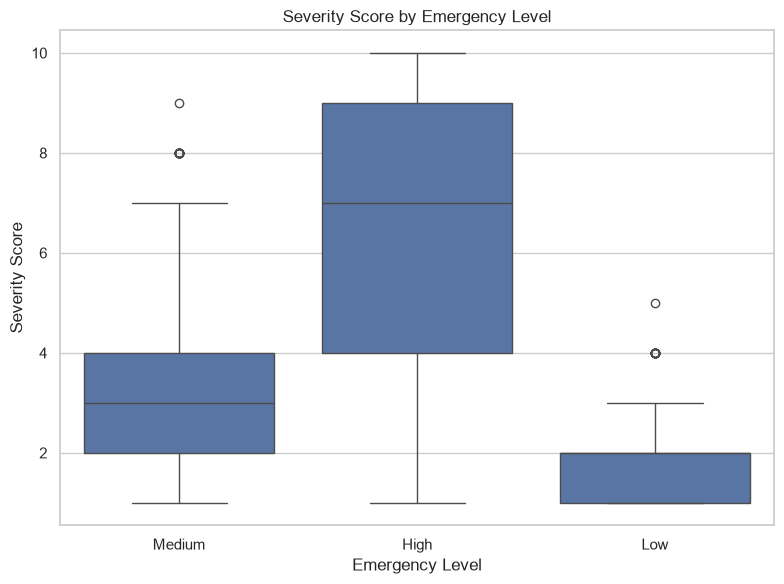

In [34]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Emergency_Level",
    y="Severity_Score"
)

plt.title("Severity Score by Emergency Level")
plt.xlabel("Emergency Level")
plt.ylabel("Severity Score")
plt.tight_layout()

plt.savefig("../visualizations/severity_by_emergency.png", dpi=300)
plt.show()

## 15. Response Time by Emergency Level

This analysis compares police, ambulance, and fire response times across emergency levels.

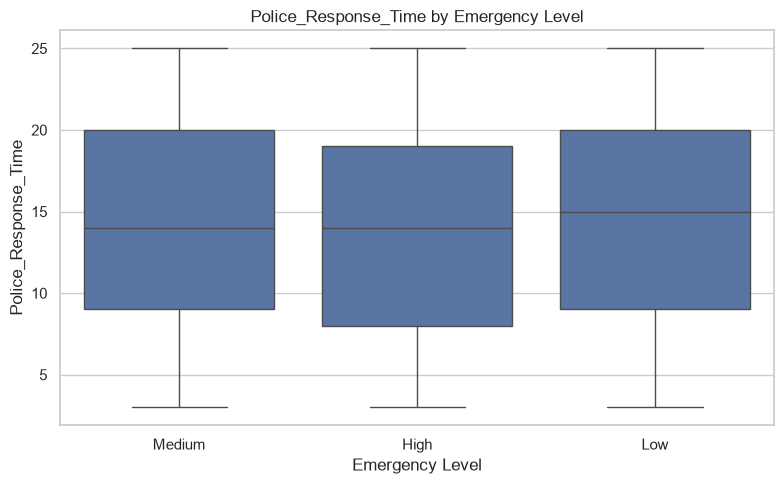

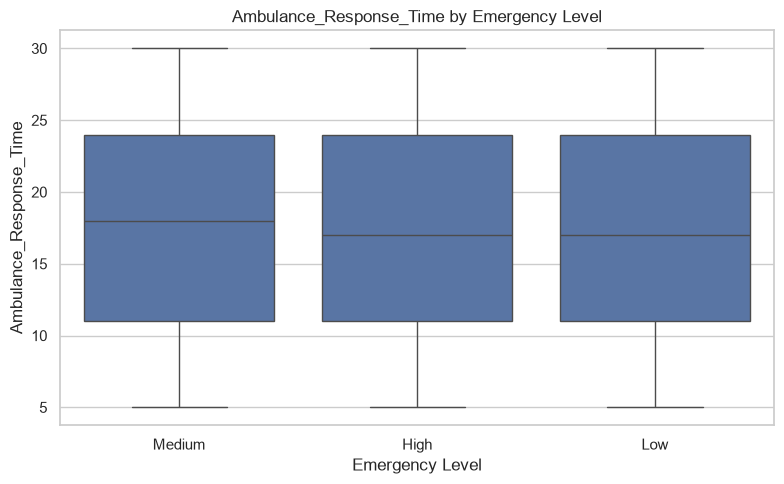

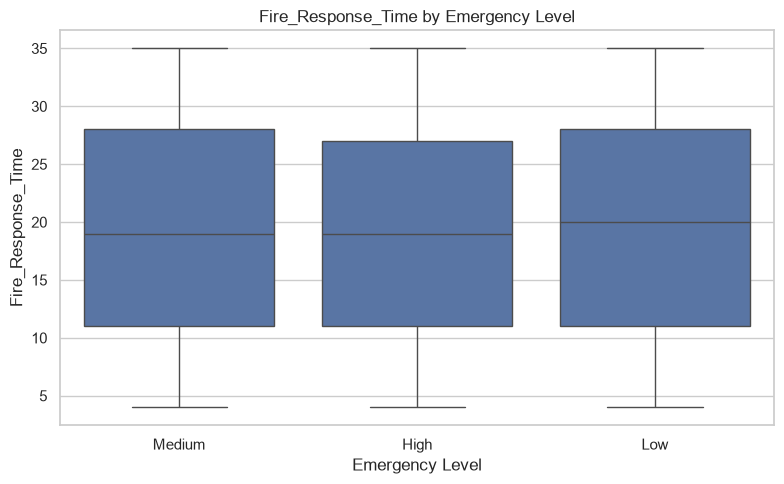

In [35]:
response_columns = [
    "Police_Response_Time",
    "Ambulance_Response_Time",
    "Fire_Response_Time"
]

for column in response_columns:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Emergency_Level",
        y=column
    )

    plt.title(f"{column} by Emergency Level")
    plt.xlabel("Emergency Level")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

## 16. Correlation Analysis

Correlation analysis is performed to understand the relationships between numerical features.
A correlation heatmap is used to visualize the strength and direction of relationships between variables.

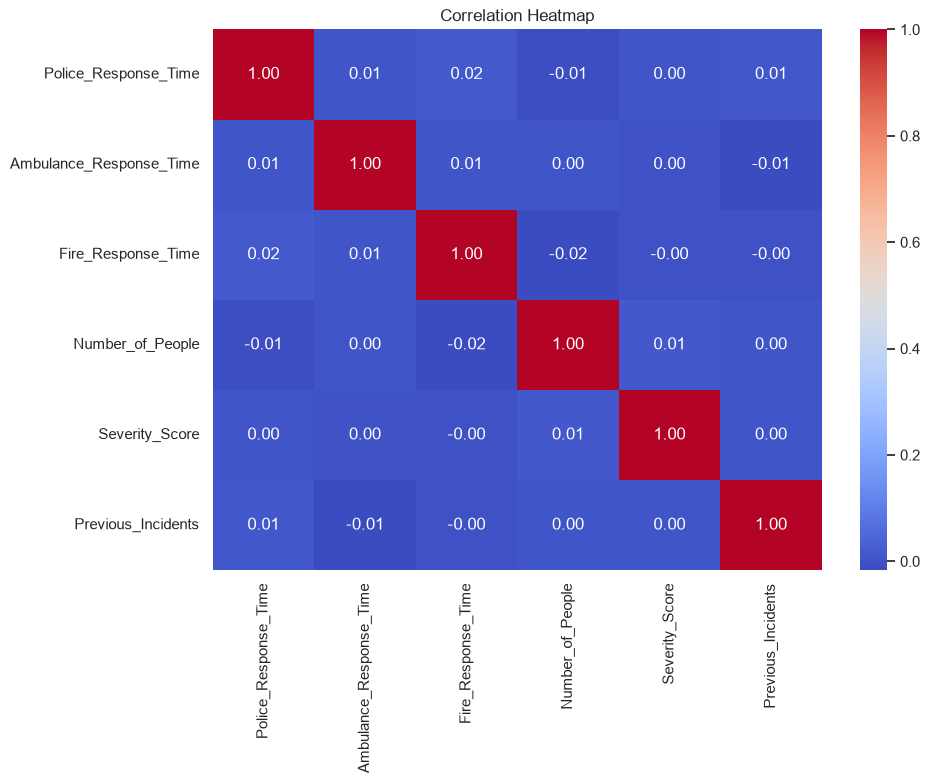

In [36]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png", dpi=300)
plt.show()

## 17. Emergency Level Percentage by Incident Type

The percentage distribution of emergency levels within each incident type is calculated to understand the severity pattern of each incident category.

In [37]:
incident_percentage = pd.crosstab(
    df["Incident_Type"],
    df["Emergency_Level"],
    normalize="index"
) * 100

display(incident_percentage.round(2))

Emergency_Level,High,Low,Medium
Incident_Type,,,
Accident,73.69,5.14,21.17
Assault,74.62,5.08,20.30
Fire,76.36,4.70,18.94
Medical,76.37,5.01,18.62
Theft,75.18,4.98,19.83


## 18. Emergency Level Percentage by Area

The percentage distribution of emergency levels within each area is calculated to compare the severity pattern across locations.

In [38]:
area_percentage = pd.crosstab(
    df["Area"],
    df["Emergency_Level"],
    normalize="index"
) * 100

display(area_percentage.round(2))

Emergency_Level,High,Low,Medium
Area,,,
Central,74.86,5.24,19.89
East,76.02,4.75,19.24
North,75.86,4.96,19.18
South,75.66,4.98,19.36
West,73.85,4.97,21.18


## 20. Conclusion

Exploratory Data Analysis was performed on the cleaned Smart City Public Safety dataset.
The analysis covered categorical variables, numerical variables, emergency levels, severity scores, response times, and correlations.
Various visualizations were used to identify patterns and relationships within the dataset.
The insights obtained from EDA can support better understanding of public safety incidents and provide a foundation for future data-driven decision-making.